In [2]:
## BB [72, 12, 6] coordinate patch
import stim


def coords_to_stim_circuit(coords):
    circuit = stim.Circuit()
    for q in sorted(coords):
        x, y = coords[q]
        circuit.append("QUBIT_COORDS", [int(q)], [float(x), float(y)])
    return circuit


def bb_72_12_6_coords():
    """Return coordinates for the BB patch with the shared fixed indexing.

    Qubit indexing:
        BB data: 0..71
        gadget edge data: 72..243, assigned by the gadget helper
        BB Z check/measurement qubits: 244..279
        BB X check/measurement qubits: 280..315
    """
    coords = {}
    for a in range(6):
        for b in range(6):
            i = 6 * a + b
            x = 2 * b
            y = 2 * a
            coords[i] = (float(x), float(y + 1))          # L_i
            coords[36 + i] = (float(x + 1), float(y))     # R_i
            coords[244 + i] = (float(x + 1), float(y + 1)) # Z_i
            coords[280 + i] = (float(x), float(y))         # X_i
    return coords


def bb_72_12_6_coords_stim():
    return coords_to_stim_circuit(bb_72_12_6_coords())


In [3]:
## reusable measurement-gadget coordinate patch
import stim


def measurement_gadget_template_coords(
    qubit_start=72,
    rows=8,
    cols=9,
    ports=20,
    spacing=2.0,
    edge_start=None,
    cycle_start=None,
    vertex_start=None,
    port_start=None,
):
    """Return coordinates for a triangular measurement gadget.

    Rows alternate ``cols, cols-1, cols, cols-1, ...``.  If only
    ``qubit_start`` is given, edge qubits, cycle-check qubits, vertex-check
    qubits, and port qubits are numbered contiguously in that order.

    ``edge_start`` is accepted as a backward-compatible alias for
    ``qubit_start``.  Explicit ``cycle_start``/``vertex_start``/``port_start``
    can be used when the gadget must match an external fixed indexing.
    """
    if edge_start is not None:
        qubit_start = int(edge_start)

    coords = {}
    row_sites = []
    for r in range(rows):
        n = cols if r % 2 == 0 else cols - 1
        row_sites.append([(r, c) for c in range(n)])

    def site_xy(site):
        r, c = site
        x0 = 0.0 if r % 2 == 0 else 0.5
        return (float(spacing * (x0 + c)), float(spacing * r))

    site_coords = {site: site_xy(site) for row in row_sites for site in row}

    site_edges = []
    for row in row_sites:
        site_edges += [(row[c], row[c + 1]) for c in range(len(row) - 1)]
    for r in range(rows - 1):
        upper, lower = row_sites[r], row_sites[r + 1]
        if len(upper) == len(lower) + 1:
            for c in range(len(lower)):
                site_edges += [(upper[c], lower[c]), (upper[c + 1], lower[c])]
        else:
            for c in range(len(upper)):
                site_edges += [(upper[c], lower[c]), (upper[c], lower[c + 1])]

    def midpoint(edge):
        a, b = edge
        xa, ya = site_coords[a]
        xb, yb = site_coords[b]
        return ((xa + xb) / 2, (ya + yb) / 2)

    site_edges = sorted(set(tuple(sorted(e)) for e in site_edges), key=lambda e: (midpoint(e)[0], midpoint(e)[1], e))

    site_triangles = []
    for r in range(rows - 1):
        upper, lower = row_sites[r], row_sites[r + 1]
        if len(upper) == len(lower) + 1:
            for c in range(len(lower)):
                site_triangles.append((upper[c], upper[c + 1], lower[c]))
            for c in range(len(lower) - 1):
                site_triangles.append((lower[c], lower[c + 1], upper[c + 1]))
        else:
            for c in range(len(upper)):
                site_triangles.append((lower[c], lower[c + 1], upper[c]))
            for c in range(len(upper) - 1):
                site_triangles.append((upper[c], upper[c + 1], lower[c + 1]))

    def centroid(tri):
        xs = [site_coords[v][0] for v in tri]
        ys = [site_coords[v][1] for v in tri]
        return (sum(xs) / 3, sum(ys) / 3)

    site_triangles = sorted(site_triangles, key=lambda t: (centroid(t)[0], centroid(t)[1], t))

    if cycle_start is None:
        cycle_start = qubit_start + len(site_edges)
    if vertex_start is None:
        vertex_start = cycle_start + len(site_triangles)
    if port_start is None:
        port_start = vertex_start + sum(len(row) for row in row_sites)

    edge_qubits = list(range(int(qubit_start), int(qubit_start) + len(site_edges)))
    cycle_check_qubits = list(range(int(cycle_start), int(cycle_start) + len(site_triangles)))
    vertex_check_qubits = list(range(int(vertex_start), int(vertex_start) + sum(len(row) for row in row_sites)))
    port_qubits = list(range(int(port_start), int(port_start) + int(ports)))

    for q, edge in zip(edge_qubits, site_edges):
        coords[q] = midpoint(edge)
    for q, tri in zip(cycle_check_qubits, site_triangles):
        coords[q] = centroid(tri)

    row_qubits = []
    site_to_vertex_qubit = {}
    q_iter = iter(vertex_check_qubits)
    for row in row_sites:
        qubit_row = []
        for site in row:
            q = next(q_iter)
            coords[q] = site_coords[site]
            site_to_vertex_qubit[site] = q
            qubit_row.append(q)
        row_qubits.append(qubit_row)

    edge_qubit_to_vertices = {
        q: (site_to_vertex_qubit[a], site_to_vertex_qubit[b])
        for q, (a, b) in zip(edge_qubits, site_edges)
    }
    triangle_vertices = [tuple(site_to_vertex_qubit[s] for s in tri) for tri in site_triangles]

    port_y = spacing * rows + spacing
    for i, q in enumerate(port_qubits):
        coords[q] = (float(spacing * i), float(port_y))

    return {
        "coords": coords,
        "row_qubits": row_qubits,
        "vertex_check_qubits": vertex_check_qubits,
        "edge_qubits": edge_qubits,
        "edge_qubit_to_vertices": edge_qubit_to_vertices,
        "cycle_check_qubits": cycle_check_qubits,
        "triangle_vertices": triangle_vertices,
        "port_qubits": port_qubits,
        "starts": {
            "edge": int(qubit_start),
            "cycle": int(cycle_start),
            "vertex": int(vertex_start),
            "port": int(port_start),
        },
        "stim_circuit": coords_to_stim_circuit(coords),
    }


def measurement_gadget_template_coords_stim(qubit_start=72, rows=8, cols=9):
    return measurement_gadget_template_coords(qubit_start=qubit_start, rows=rows, cols=cols)["stim_circuit"]


In [4]:
## combined BB + measurement-gadget coordinate layout

def shift_coords(coords, dx=0.0, dy=0.0):
    return {q: (float(x + dx), float(y + dy)) for q, (x, y) in coords.items()}


def x_span(coords):
    xs = [x for x, y in coords.values()]
    return min(xs), max(xs)


def y_span(coords):
    ys = [y for x, y in coords.values()]
    return min(ys), max(ys)


def center_x_shift(inner_coords, outer_coords):
    inner_min, inner_max = x_span(inner_coords)
    outer_min, outer_max = x_span(outer_coords)
    return (outer_min + outer_max) / 2 - (inner_min + inner_max) / 2


def combined_bb72_measurement_gadget_coords(bb_gap=3.0):
    """Return one coordinate circuit for the BB patch plus gadget."""
    bb_coords = bb_72_12_6_coords()
    gadget = measurement_gadget_template_coords(
        qubit_start=72,
        rows=8,
        cols=9,
        cycle_start=316,
        vertex_start=421,
        port_start=489,
    )
    gadget_coords = gadget["coords"]

    lattice_and_checks = (
        gadget["vertex_check_qubits"]
        + gadget["edge_qubits"]
        + gadget["cycle_check_qubits"]
    )
    lattice_coords = {q: gadget_coords[q] for q in lattice_and_checks}
    port_coords = {q: gadget_coords[q] for q in gadget["port_qubits"]}
    lattice_dx = center_x_shift(lattice_coords, bb_coords)
    port_dx = center_x_shift(port_coords, bb_coords)
    dy = y_span(bb_coords)[1] + float(bb_gap) - y_span(gadget_coords)[0]

    shifted_gadget_coords = {}
    for q, (x, y) in gadget_coords.items():
        dx = port_dx if q in gadget["port_qubits"] else lattice_dx
        shifted_gadget_coords[q] = (float(x + dx), float(y + dy))

    coords = {**bb_coords, **shifted_gadget_coords}
    return {
        "coords": coords,
        "stim_circuit": coords_to_stim_circuit(coords),
        "bb_qubits": sorted(bb_coords),
        "gadget_qubits": sorted(shifted_gadget_coords),
        "gadget_vertex_check_qubits": gadget["vertex_check_qubits"],
        "gadget_edge_qubits": gadget["edge_qubits"],
        "gadget_cycle_check_qubits": gadget["cycle_check_qubits"],
        "gadget_port_qubits": gadget["port_qubits"],
        "gadget_row_qubits": gadget["row_qubits"],
        "gadget_edge_qubit_to_vertices": gadget["edge_qubit_to_vertices"],
        "gadget_triangle_vertices": gadget["triangle_vertices"],
        "gadget_shift": {
            "lattice_and_checks": (float(lattice_dx), float(dy)),
            "ports": (float(port_dx), float(dy)),
        },
    }


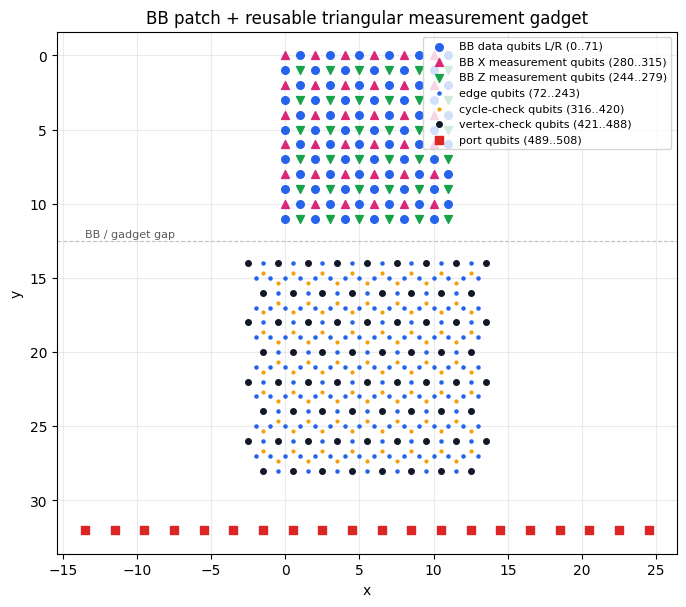

gadget shift: {'lattice_and_checks': (-2.5, 14.0), 'ports': (-13.5, 14.0)}
BB patch qubits: 144 0 315
vertex-check qubits: 68 421 488
edge qubits: 172 72 243
cycle-check qubits: 105 316 420
port qubits: 20 489 508


In [5]:
## Plot combined BB + measurement-gadget coordinate layout
import matplotlib.pyplot as plt


def _range_label(name, qubits):
    return f"{name} ({min(qubits)}..{max(qubits)})"


def plot_combined_bb72_measurement_gadget_layout(layout=None, label_qubits=False, figsize=(8, 11)):
    """Plot the 144-qubit BB patch plus reusable measurement gadget."""
    if layout is None:
        layout = combined_bb72_measurement_gadget_coords()

    coords = layout["coords"]
    bb_data_qubits = list(range(72))
    bb_z_qubits = sorted(q for q in layout["bb_qubits"] if 244 <= q < 280)
    bb_x_qubits = sorted(q for q in layout["bb_qubits"] if 280 <= q < 316)

    groups = [
        (bb_data_qubits, "#2563eb", "BB data qubits L/R (0..71)", "o", 30),
        (bb_x_qubits, "#db2777", _range_label("BB X measurement qubits", bb_x_qubits), "^", 32),
        (bb_z_qubits, "#16a34a", _range_label("BB Z measurement qubits", bb_z_qubits), "v", 32),
        (layout["gadget_edge_qubits"], "#2563eb", _range_label("edge qubits", layout["gadget_edge_qubits"]), ".", 20),
        (layout["gadget_cycle_check_qubits"], "#f59e0b", _range_label("cycle-check qubits", layout["gadget_cycle_check_qubits"]), ".", 16),
        (layout["gadget_vertex_check_qubits"], "#111827", _range_label("vertex-check qubits", layout["gadget_vertex_check_qubits"]), "o", 16),
        (layout["gadget_port_qubits"], "#dc2626", _range_label("port qubits", layout["gadget_port_qubits"]), "s", 32),
    ]

    fig, ax = plt.subplots(figsize=figsize)
    for qubits, color, label, marker, size in groups:
        xs = [coords[q][0] for q in qubits]
        ys = [coords[q][1] for q in qubits]
        ax.scatter(xs, ys, s=size, color=color, marker=marker, label=label, zorder=3)

    if label_qubits:
        for q, (x, y) in coords.items():
            ax.text(x, y + 0.12, str(q), ha="center", va="bottom", fontsize=4.5)

    bb_ys = [coords[q][1] for q in layout["bb_qubits"]]
    gadget_ys = [coords[q][1] for q in layout["gadget_qubits"]]
    split_y = (max(bb_ys) + min(gadget_ys)) / 2
    ax.axhline(split_y, color="0.75", linewidth=0.8, linestyle="--", zorder=1)
    ax.text(min(x for x, y in coords.values()), split_y - 0.25, "BB / gadget gap", fontsize=8, color="0.35")

    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("BB patch + reusable triangular measurement gadget")
    ax.legend(loc="upper right", fontsize=8)
    plt.show()
    return fig, ax


combined_layout = combined_bb72_measurement_gadget_coords()
plot_combined_bb72_measurement_gadget_layout(combined_layout, label_qubits=False)
print("gadget shift:", combined_layout["gadget_shift"])
print("BB patch qubits:", len(combined_layout["bb_qubits"]), min(combined_layout["bb_qubits"]), max(combined_layout["bb_qubits"]))
print("vertex-check qubits:", len(combined_layout["gadget_vertex_check_qubits"]), min(combined_layout["gadget_vertex_check_qubits"]), max(combined_layout["gadget_vertex_check_qubits"]))
print("edge qubits:", len(combined_layout["gadget_edge_qubits"]), min(combined_layout["gadget_edge_qubits"]), max(combined_layout["gadget_edge_qubits"]))
print("cycle-check qubits:", len(combined_layout["gadget_cycle_check_qubits"]), min(combined_layout["gadget_cycle_check_qubits"]), max(combined_layout["gadget_cycle_check_qubits"]))
print("port qubits:", len(combined_layout["gadget_port_qubits"]), min(combined_layout["gadget_port_qubits"]), max(combined_layout["gadget_port_qubits"]))


fixed lattice translation: (-1, -2)
fixed edge qubits used: 43
cycle rows: 22


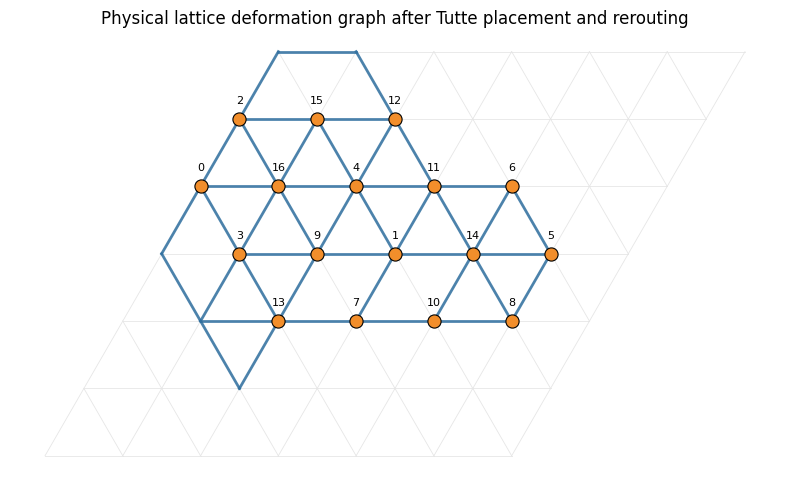

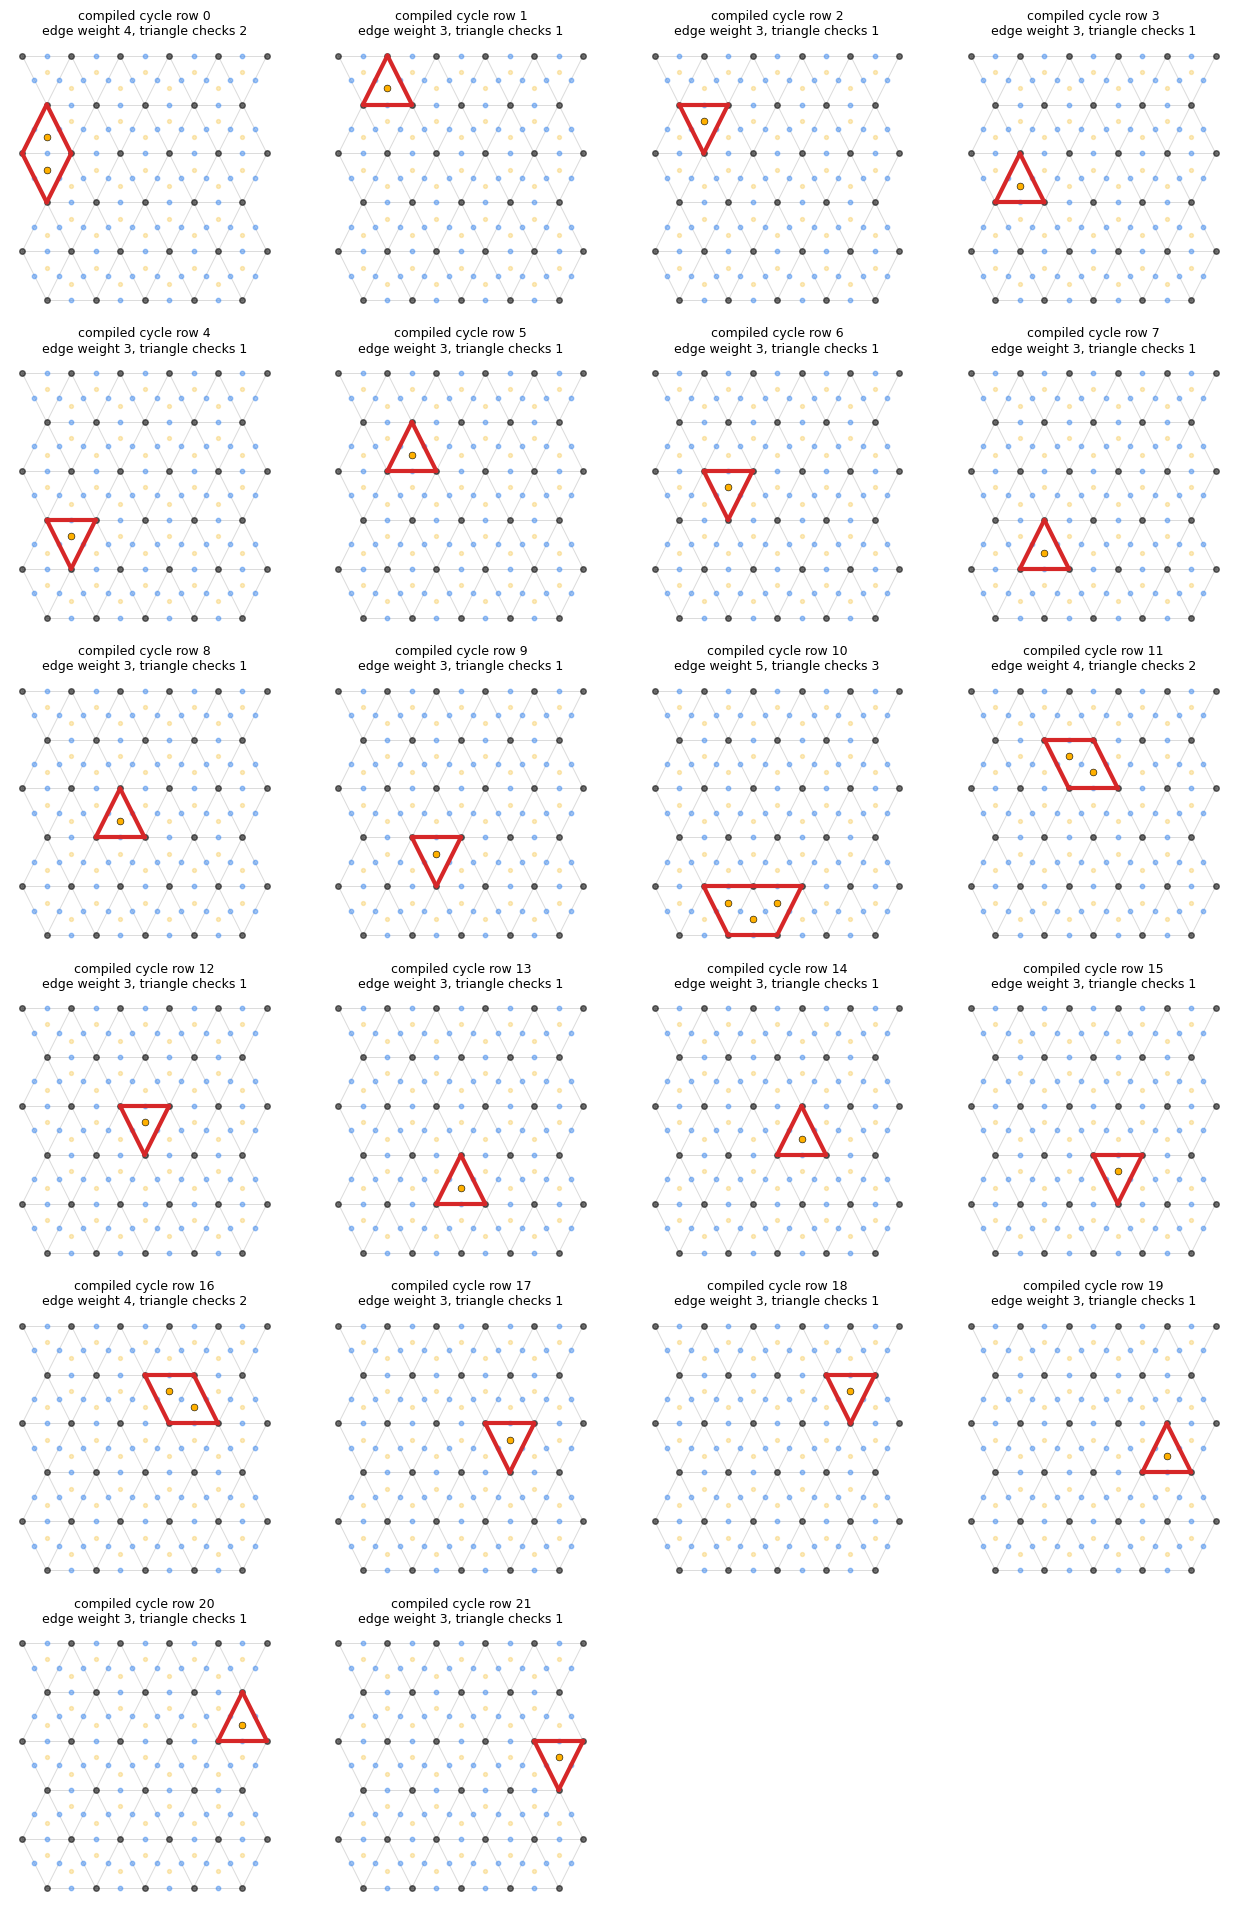

In [6]:
## Visualize compiled cycle checks on the fixed 8/7-row Stim gadget
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import math
import numpy as np
import matplotlib.pyplot as plt

from deform_triangular_lattice import deform_logical_to_tri_lattice
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)

from deform_triangular_lattice import deform_logical_to_tri_lattice


def compiled_fixed_gadget_deformation(bb_memory_result=None, logical_index=0, **tri_layout_kwargs):
    """Compile a deformation onto the fixed Stim gadget indexing.

    If bb_memory_result is omitted, build the default BB(72,12,6) Z-logical
    deformation directly. This avoids depending on the old notebook variable
    named ``bb_memory``.
    """
    if bb_memory_result is None:
        BB_code = codes.BBCode(
            orders={x: 6, y: 6},
            poly_a=x**3 + y + y**2,
            poly_b=y**3 + x + x**2,
        )
        logical = BB_code.get_logical_ops(Pauli.Z)[logical_index]
        deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.Z, logical)
    elif isinstance(bb_memory_result, dict) and "deformation_result" in bb_memory_result:
        deformation_result = bb_memory_result["deformation_result"]
    else:
        deformation_result = bb_memory_result

    fixed_result = deform_logical_to_tri_lattice(
        deformation_result,
        plot=True,
        **tri_layout_kwargs,
    )
    try:
        plt.close(fixed_result["fig"])
    except Exception:
        pass
    return fixed_result



def plot_fixed_gadget_used_outline(fixed_result=None, label_vertices=True, label_edge_qubits=False, figsize=(8, 6)):
    """Plot the full compiled auxiliary graph outline on the fixed Stim gadget."""
    if fixed_result is None:
        fixed_result = compiled_fixed_gadget_deformation()

    template = fixed_result["fixed_template"]
    coords = template.coords
    used_edge_qubits = sorted(set(fixed_result["fixed_edge_qubits_used"]))

    fig, ax = plt.subplots(figsize=figsize)

    # Full reusable triangular gadget background.
    for q_edge, (a, b) in template.edge_qubit_to_vertices.items():
        xa, ya = coords[a]
        xb, yb = coords[b]
        ax.plot([xa, xb], [ya, yb], color="0.90", linewidth=0.8, zorder=0)

    # Compiled physical auxiliary graph: one highlighted segment per used edge qubit.
    for q_edge in used_edge_qubits:
        a, b = template.edge_qubit_to_vertices[q_edge]
        xa, ya = coords[a]
        xb, yb = coords[b]
        ax.plot([xa, xb], [ya, yb], color="#2f6f9f", linewidth=2.4, alpha=0.90, zorder=2)
        if label_edge_qubits:
            xq, yq = coords[q_edge]
            ax.text(xq, yq, str(q_edge), color="#174a6a", fontsize=6, ha="center", va="center", zorder=4)

    # Original deformation graph vertices after exact placement onto the fixed gadget.
    site_to_fixed_vertex = fixed_result["site_to_fixed_vertex_check_qubit"]
    graph_vertex_to_site = fixed_result["vertex_sites"]
    plotted_vertices = []
    for graph_vertex, site in graph_vertex_to_site.items():
        if site not in site_to_fixed_vertex:
            continue
        q_vertex = site_to_fixed_vertex[site]
        xq, yq = coords[q_vertex]
        plotted_vertices.append((int(graph_vertex), q_vertex, xq, yq))

    if plotted_vertices:
        pts = np.array([(x, y) for _, _, x, y in plotted_vertices], dtype=float)
        ax.scatter(pts[:, 0], pts[:, 1], s=90, color="#f28e2b", edgecolor="black", linewidth=0.8, zorder=5)
        if label_vertices:
            for graph_vertex, q_vertex, xq, yq in plotted_vertices:
                ax.text(xq, yq - 0.32, str(graph_vertex), ha="center", va="bottom", fontsize=8, color="0.15", zorder=6)

    ax.set_title("Compiled auxiliary graph outline on fixed 8/7 Stim gadget")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    fig.tight_layout()
    return fig, ax

def plot_fixed_gadget_cycle_checks(fixed_result=None, max_cols=4, figsize_per_panel=(3.2, 3.2), label_edges=False):
    """Plot every compiled cycle check on the actual fixed 8/7 triangular Stim gadget.

    Vertex-check qubits are drawn at triangular-lattice crossings.
    Edge qubits are drawn at edge midpoints.
    Cycle rows are highlighted by their compiled fixed edge-qubit support.
    """
    if fixed_result is None:
        fixed_result = compiled_fixed_gadget_deformation()

    template = fixed_result["fixed_template"]
    coords = template.coords
    H_cycle = np.asarray(fixed_result["H_opposite_basis_new"], dtype=np.uint8)
    edge_qubits = set(template.edge_qubits)
    n_cycles = H_cycle.shape[0]

    if n_cycles == 0:
        print("No cycle checks in this compiled deformation.")
        return None, None

    ncols = min(max_cols, n_cycles)
    nrows = int(math.ceil(n_cycles / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    # Draw the whole fixed 8/7-row gadget in every panel so the compiled cycle
    # can be checked against the actual Stim-coordinate lattice.
    all_vertex_edges = list(template.edge_qubit_to_vertices.items())
    vertex_pts = np.array([coords[q] for q in template.vertex_check_qubits], dtype=float)
    all_edge_pts = np.array([coords[q] for q in template.edge_qubits], dtype=float)
    cycle_pts = np.array([coords[q] for q in template.cycle_check_qubits], dtype=float)

    for row, ax in enumerate(axes.flat):
        if row >= n_cycles:
            ax.axis("off")
            continue

        for q_edge, (a, b) in all_vertex_edges:
            xa, ya = coords[a]
            xb, yb = coords[b]
            ax.plot([xa, xb], [ya, yb], color="0.86", linewidth=0.7, zorder=0)

        if len(cycle_pts):
            ax.scatter(cycle_pts[:, 0], cycle_pts[:, 1], s=8, color="#f6c343", alpha=0.35, zorder=1, label="cycle-check qubits")
        if len(all_edge_pts):
            ax.scatter(all_edge_pts[:, 0], all_edge_pts[:, 1], s=10, color="#2f80ed", alpha=0.45, zorder=2, label="edge qubits")
        if len(vertex_pts):
            ax.scatter(vertex_pts[:, 0], vertex_pts[:, 1], s=16, color="black", alpha=0.55, zorder=3, label="vertex-check qubits")

        support = [int(q) for q in np.flatnonzero(H_cycle[row]) if int(q) in edge_qubits]
        for q_edge in support:
            a, b = template.edge_qubit_to_vertices[q_edge]
            xa, ya = coords[a]
            xb, yb = coords[b]
            ax.plot([xa, xb], [ya, yb], color="#d62728", linewidth=3.0, solid_capstyle="round", zorder=4)
            if label_edges:
                xq, yq = coords[q_edge]
                ax.text(xq, yq, str(q_edge), color="#8b0000", fontsize=6, ha="center", va="center", zorder=5)

        triangle_checks = fixed_result.get("cycle_row_to_check_qubits", {}).get(row, [])
        for q_cycle in triangle_checks:
            if q_cycle in coords:
                xq, yq = coords[q_cycle]
                ax.scatter([xq], [yq], s=24, color="#ffb000", edgecolor="black", linewidth=0.4, zorder=6)

        ax.set_title(
            f"compiled cycle row {row}\n"
            f"edge weight {len(support)}, triangle checks {len(triangle_checks)}",
            fontsize=9,
        )
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.axis("off")

    fig.tight_layout()
    return fig, axes


fixed_gadget_deformation = compiled_fixed_gadget_deformation()
print("fixed lattice translation:", fixed_gadget_deformation["lattice_translation"])
print("fixed edge qubits used:", len(fixed_gadget_deformation["fixed_edge_qubits_used"]))
print("cycle rows:", fixed_gadget_deformation["H_opposite_basis_new"].shape[0])

#fig_fixed_outline, ax_fixed_outline = plot_fixed_gadget_used_outline(fixed_gadget_deformation)
fig_fixed_cycles, axes_fixed_cycles = plot_fixed_gadget_cycle_checks(fixed_gadget_deformation)


## Generate Stim circuit

In [56]:
from stimbposd import BPOSD
import matplotlib.pyplot as plt
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import numpy as np
import stim
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)
from deform_triangular_lattice import deform_logical_to_tri_lattice

### BB code memory performance code-capacity reference

In [57]:
# small BB example BB [[36, 8, 4]]

import qldpc

import numpy as np

BB36_STABILIZERS = """
XIIXIXXIIIIIXIIIIIIIIIXIIIIIIIIIIIII
IXIXXIIXIIIIIXIIIIIIIIIXIIIIIIIIIIII
IIXIXXIIXIIIIIXIIIIIIXIIIIIIIIIIIIII
IIIIIIXIIXIXXIIIIIXIIIIIIIIIXIIIIIII
IIIIIIIXIXXIIXIIIIIXIIIIIIIIIXIIIIII
IIIIIIIIXIXXIIXIIIIIXIIIIIIXIIIIIIII
IIIIIIIIIIIIXIIXIXXIIIIIXIIIIIIIIIXI
IIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIIIIX
IIIIIIIIIIIIIIXIXXIIXIIIIIXIIIIIIXII
IIIIXIIIIIIIIIIIIIXIIXIXXIIIIIXIIIII
IIIIIXIIIIIIIIIIIIIXIXXIIXIIIIIXIIII
IIIXIIIIIIIIIIIIIIIIXIXXIIXIIIIIXIII
XIIIIIIIIIXIIIIIIIIIIIIIXIIXIXXIIIII
XIIIIIXIIIIIIIIIXIIIIIIIIIIIIIXIIXIX
ZZIZIIIIIIIIIIIIIIIIZIIIIIIZIIIIIZII
IZZIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZI
ZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZIIIIIZ
IIIZIIZZIZIIIIIIIIIIIIIIIIZIIIIIIZII
IIIIZIIZZIZIIIIIIIIIIIIIZIIIIIIIIIZI
IIIIIZZIZIIZIIIIIIIIIIIIIZIIIIIIIIIZ
IIIZIIIIIZIIZZIZIIIIIIIIIIIIIIIIZIII
IIIIZIIIIIZIIZZIZIIIIIIIIIIIIIZIIIII
IIIIIZIIIIIZZIZIIZIIIIIIIIIIIIIZIIII
IIZIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIIII
ZIIIIIIIIIZIIIIIZIIZZIZIIIIIIIIIIIII
IZIIIIIIIIIZIIIIIZZIZIIZIIIIIIIIIIII
IIIIIIIIZIIIIIIZIIIIIZIIZZIZIIIIIIII
IIIIIIIIIIIIIIZIIIIIIZIIIIIZIIZZIZII
""".strip().splitlines()

BB36_LOGICALS = """
IIIIIIIIIIXXIIIIIIIIIIXXXXIIIIXXIIII
IIIIIIIIIIIIIIIIIIZIZIIIZIZZZIIIIIII
IIIIIIIIIIIXIIIIIIXXXIIXXXXIIXIXIXXI
IIIIIIIIIIZIIIIIZIIZIIIIIIIZIIIZIZII
IIIIIIIIIIIXIIIIIIIIXIXIIIXIIXIXIXIX
IIIIIIIIIIIZIIIIIZIZIIIIIIIZZZIZIZZZ
IIIIIIIIIIIXIIIIIIIXIXXXIXIIIXIXIIII
IIIIIIIIIIZZIIIIZZZZIIIIIIIIIIZZIIII
IIIIIIIIIIIXIIIIXIIIIIXXIIIIIXXXIIIX
IIIIIIIIIIIIIIIIIIIIIIIIZIZIIIZIZZZI
IIIIIIIIIIIXIIIIIXIIIIIIIIIIIXIIIIIX
IIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIZZZIZ
IIIIIIIIIIIIIIIIIIIIIIIIXIXXXIIIIXXI
IIIIIIIIIIZIIIIIIIIZIIIIIZIZIIIIIIII
IIIIIIIIIIIIIIIIIIIIIIIIIXXXIXIIIXIX
IIIIIIIIIIIZIIIIIIIZIIIIIZIZZZIIIIII
""".strip().splitlines()


def bb36_parse_checks(stabilizer_strings):
    lengths = {len(row) for row in stabilizer_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent stabilizer string lengths: {sorted(lengths)}")
    x_rows = [row for row in stabilizer_strings if "X" in row]
    z_rows = [row for row in stabilizer_strings if "Z" in row]
    Hx = np.array([[c == "X" for c in row] for row in x_rows], dtype=np.uint8)
    Hz = np.array([[c == "Z" for c in row] for row in z_rows], dtype=np.uint8)
    return Hx, Hz


def bb36_parse_logicals(logical_strings):
    lengths = {len(row) for row in logical_strings}
    if len(lengths) != 1:
        raise ValueError(f"Inconsistent logical string lengths: {sorted(lengths)}")
    if len(logical_strings) % 2:
        raise ValueError("Expected alternating X/Z logical rows")
    logical_X = np.array([[c == "X" for c in row] for row in logical_strings[0::2]], dtype=np.uint8)
    logical_Z = np.array([[c == "Z" for c in row] for row in logical_strings[1::2]], dtype=np.uint8)
    return logical_X, logical_Z



Hx, Hz = bb36_parse_checks(BB36_STABILIZERS)
logical_X, logical_Z = bb36_parse_logicals(BB36_LOGICALS)
H = np.vstack([
    np.hstack([Hx, np.zeros((Hx.shape[0], Hz.shape[1]), dtype=np.uint8)]),
    np.hstack([np.zeros((Hz.shape[0], Hx.shape[1]), dtype=np.uint8), Hz]),
])


class BB36Code:
    def __init__(self):
        self.label = "BB [[36,8,4]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


class BB144Code:


    def __init__(self):
        self.label = "BB [[144,12,12]]"
        self.Hx = Hx
        self.Hz = Hz
        self.logical_X = logical_X
        self.logical_Z = logical_Z
        self.matrix = H.astype(np.uint8)

    def get_logical_ops(self, basis):
        if basis == Pauli.X or str(basis).upper().endswith("X"):
            return self.logical_X
        if basis == Pauli.Z or str(basis).upper().endswith("Z"):
            return self.logical_Z
        raise ValueError(f"Unknown basis: {basis}")


a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 12, y: 6}


def BB144Code():
    return codes.BBCode(orders=orders, poly_a=a, poly_b=b)

BB36 = BB36Code()
BB144 = BB144Code()


# def get_BB_98_6_12():
#     return codes.BBCode(
#         orders={x: 7, y: 7},
#         poly_a=x**3 + y**3 + y**4,
#         poly_b=y**6 + x**2 + x**5,
#     )

# def get_BB_72_12_6():
#     return codes.BBCode(
#         orders={x: 6, y: 6},
#         poly_a=x**3 + y + y**2,
#         poly_b=y**3 + x + x**2,
#     )


detectors: 1800
observables: 12
L0 terms: 624
BB memory Z, p=1.00e-02, avg raw=0.4918, avg decoded=0
detectors: 1800
observables: 12
L0 terms: 624
BB memory Z, p=3.16e-02, avg raw=0.5037, avg decoded=8.333e-05
detectors: 1800
observables: 12
L0 terms: 624
BB memory Z, p=1.00e-01, avg raw=0.4995, avg decoded=0.277


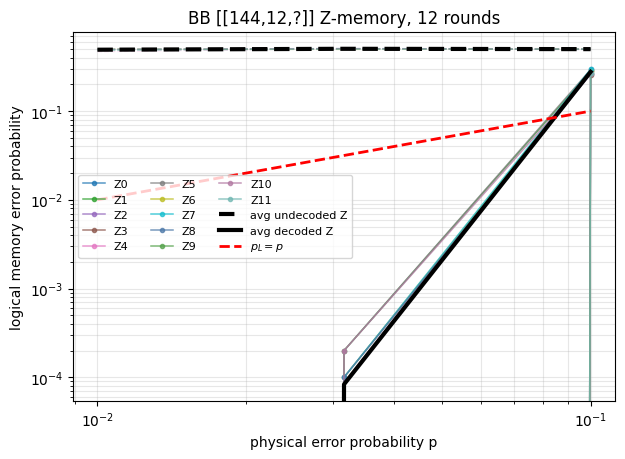

detectors: 1800
observables: 12
L0 terms: 576


KeyboardInterrupt: 

In [64]:
# BB code memory: code-capacity MPP stabilizer rounds + simple BPOSD decoder

def bb_get_PCMS(H):
    H = np.asarray(H, dtype=np.uint8)
    n_rows, n_cols = H.shape
    n_data = n_cols // 2
    n_checks = n_rows // 2
    return H[:n_checks, :n_data], H[n_checks:, n_data:]


def bb_is_x_basis(basis):
    return basis == Pauli.X or str(basis).upper().endswith("X")


def bb_pauli_string(pauli, row):
    return stim.PauliString("+" + "".join(pauli if b else "_" for b in row))


def bb_prepare_logical_memory_state(BB_code, memory_basis=Pauli.Z):
    """Perfectly prepare all logicals in +1 eigenstates of memory_basis."""
    Hx, Hz = bb_get_PCMS(BB_code.matrix)
    logical_pauli = "X" if bb_is_x_basis(memory_basis) else "Z"

    stabilizers = []
    stabilizers += [bb_pauli_string("X", row) for row in Hx]
    stabilizers += [bb_pauli_string("Z", row) for row in Hz]
    stabilizers += [
        bb_pauli_string(logical_pauli, np.asarray(logical, dtype=np.uint8))
        for logical in BB_code.get_logical_ops(memory_basis)
    ]
    return stim.Tableau.from_stabilizers(
        stabilizers,
        allow_redundant=True,
        allow_underconstrained=False,
    ).to_circuit()


def bb_append_code_capacity_noise(circuit, n_data, p):
    if p:
        circuit.append("DEPOLARIZE1", list(range(n_data)), p)


def bb_append_mpp_check(circuit, pauli, support):
    targets = []
    for q in np.flatnonzero(support):
        if targets:
            targets.append(stim.target_combiner())
        targets.append(stim.target_x(int(q)) if pauli == "X" else stim.target_z(int(q)))
    if not targets:
        raise ValueError("Cannot measure an empty stabilizer row with MPP")
    circuit.append("MPP", targets)


def bb_rec_abs(circuit, measurement_index):
    return stim.target_rec(int(measurement_index) - circuit.num_measurements)


def bb_measure_stabilizer_round(circuit, Hx, Hz):
    records = {"x": [], "z": []}
    for row in Hx:
        bb_append_mpp_check(circuit, "X", row)
        records["x"].append(circuit.num_measurements - 1)
    for row in Hz:
        bb_append_mpp_check(circuit, "Z", row)
        records["z"].append(circuit.num_measurements - 1)
    return records


def bb_add_round_detectors(circuit, previous, current):
    for kind in ["x", "z"]:
        for old, new in zip(previous[kind], current[kind]):
            circuit.append("DETECTOR", [bb_rec_abs(circuit, old), bb_rec_abs(circuit, new)])


def bb_measure_data(circuit, n_data, memory_basis=Pauli.Z):
    # No noise 
    if bb_is_x_basis(memory_basis):
        circuit.append("H", list(range(n_data)))
    start = circuit.num_measurements
    circuit.append("M", list(range(n_data)))
    return [start + q for q in range(n_data)]


def bb_add_final_detectors(circuit, Hx, Hz, last_records, data_records, memory_basis=Pauli.Z):
    # Only the stabilizer type matching the final data-measurement basis can be closed.
    checks = Hx if bb_is_x_basis(memory_basis) else Hz
    kind = "x" if bb_is_x_basis(memory_basis) else "z"
    for i, row in enumerate(checks):
        targets = [bb_rec_abs(circuit, data_records[int(q)]) for q in np.flatnonzero(row)]
        targets.append(bb_rec_abs(circuit, last_records[kind][i]))
        circuit.append("DETECTOR", targets)


def bb_add_memory_observables(circuit, BB_code, memory_basis, data_records, logical_indices=None):
    logicals = BB_code.get_logical_ops(memory_basis)
    if logical_indices is None:
        logical_indices = range(len(logicals))
    for obs_i, logical_i in enumerate(logical_indices):
        logical = np.asarray(logicals[logical_i], dtype=np.uint8)
        targets = [bb_rec_abs(circuit, data_records[int(q)]) for q in np.flatnonzero(logical)]
        circuit.append("OBSERVABLE_INCLUDE", targets, obs_i)


def bb_add_initial_detectors(circuit, current):
    for kind in ["x", "z"]:
        for m in current[kind]:
            circuit.append("DETECTOR", [bb_rec_abs(circuit, m)])


def bb_memory_circuit(BB_code, memory_basis=Pauli.Z, rounds=12, p=0.0, logical_indices=None):
    Hx, Hz = bb_get_PCMS(BB_code.matrix)
    n_data = Hx.shape[1]

    circuit = stim.Circuit()
    circuit += bb_prepare_logical_memory_state(BB_code, memory_basis)

    previous = None
    for _ in range(rounds):
        # One memory interval per round, followed by one full syndrome extraction.
        bb_append_code_capacity_noise(circuit, n_data, p)
        current = bb_measure_stabilizer_round(circuit, Hx, Hz)
        if previous is None:
            # Perfect preparation makes the first noiseless syndrome deterministic.
            bb_add_initial_detectors(circuit, current)
        else:
            bb_add_round_detectors(circuit, previous, current)
        previous = current
        circuit.append("TICK")

    # No extra data noise here: final readout immediately closes the last syndrome.
    data_records = bb_measure_data(circuit, n_data, memory_basis=memory_basis)
    bb_add_final_detectors(circuit, Hx, Hz, previous, data_records, memory_basis=memory_basis)
    bb_add_memory_observables(circuit, BB_code, memory_basis, data_records, logical_indices=logical_indices)
    return circuit


def bb_estimate_memory_error_rates(BB_code, memory_basis, p, rounds=12, shots=1000, logical_indices=None):
    circuit = bb_memory_circuit(
        BB_code,
        memory_basis=memory_basis,
        rounds=rounds,
        p=float(p),
        logical_indices=logical_indices,
    )
    dem = circuit.detector_error_model(
        decompose_errors=True,
        ignore_decomposition_failures=True,
    )

    print("detectors:", circuit.num_detectors)
    print("observables:", circuit.num_observables)
    print("L0 terms:", str(dem).count("L0"))

    
    decoder = BPOSD(
        dem,
        bp_method="ms",
        schedule="serial",
        ms_scaling_factor=0.625,
        osd_method="OSD_CS",
        osd_order=5,
        max_bp_iters=20,
    )

    dets, obs = circuit.compile_detector_sampler().sample(shots, separate_observables=True)
    pred = decoder.decode_batch(dets)

    obs = np.asarray(obs).reshape(shots, -1)
    pred = np.asarray(pred).reshape(shots, -1)
    raw = np.mean(obs, axis=0)
    decoded = np.mean(pred != obs, axis=0)
    return raw.astype(float), decoded.astype(float), circuit


def bb_code_label(BB_code):
    if hasattr(BB_code, "label"):
        return BB_code.label
    n = BB_code.matrix.shape[1] // 2
    k = len(BB_code.get_logical_ops(Pauli.Z))
    return f"BB [[{n},{k},?]]"


def bb_run_memory_sweep(
    BB_code=None,
    memory_basis=Pauli.Z,
    ps=None,
    rounds=12,
    shots=1000,
    logical_indices=None,
):
    if BB_code is None:
        BB_code = BB144Code()

    if ps is None:
        ps = np.logspace(-6, -2, 10)

    logicals = BB_code.get_logical_ops(memory_basis)
    
    if logical_indices is None:
        logical_indices = list(range(len(logicals)))
    logical_indices = list(logical_indices)

    raw = np.zeros((len(logical_indices), len(ps)))
    decoded = np.zeros_like(raw)
    last_circuit = None
    basis_name = "X" if bb_is_x_basis(memory_basis) else "Z"

    for j, p in enumerate(ps):
        raw[:, j], decoded[:, j], last_circuit = bb_estimate_memory_error_rates(
            BB_code,
            memory_basis=memory_basis,
            p=float(p),
            rounds=rounds,
            shots=shots,
            logical_indices=logical_indices,
        )
        print(
            f"BB memory {basis_name}, p={p:.2e}, "
            f"avg raw={np.mean(raw[:, j]):.4g}, avg decoded={np.mean(decoded[:, j]):.4g}"
        )

    return {
        "ps": np.asarray(ps, dtype=float),
        "rounds": int(rounds),
        "shots": int(shots),
        "basis": basis_name,
        "logical_indices": logical_indices,
        "raw": raw,
        "decoded": decoded,
        "last_circuit": last_circuit,
        "code_label": bb_code_label(BB_code),
    }


def bb_plot_memory_sweep(result, ax=None):
    ps = result["ps"]
    raw = result["raw"]
    decoded = result["decoded"]
    basis = result["basis"]
    logical_indices = result["logical_indices"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.8))
    else:
        fig = ax.figure

    colors = [
        "#1f77b4", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#4c78a8", "#54a24b", "#b279a2", "#72b7b2",
    ]
    for i, logical_i in enumerate(logical_indices):
        color = colors[i % len(colors)]
        ax.loglog(ps, raw[i], "--", color=color, alpha=0.22, linewidth=0.9)
        ax.loglog(ps, decoded[i], "o-", color=color, alpha=0.75, linewidth=1.1, markersize=3, label=f"{basis}{logical_i}")

    ax.loglog(ps, np.mean(raw, axis=0), "k--", linewidth=3.0, label=f"avg undecoded {basis}")
    ax.loglog(ps, np.mean(decoded, axis=0), "k-", linewidth=3.0, label=f"avg decoded {basis}")
    ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")
    ax.set_title(f"{result.get('code_label', 'BB code')} {basis}-memory, {result['rounds']} rounds")
    ax.set_xlabel("physical error probability p")
    ax.set_ylabel("logical memory error probability")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()
    return fig, ax

bb_memory_code = BB144Code()
bb_memory_ps = np.logspace(-2, -1, 3)
bb_memory_rounds = 12
bb_memory_shots = 10000

bb_memory_results = {}
for bb_memory_basis in [Pauli.Z, Pauli.X]:
    res = bb_run_memory_sweep(
        BB_code=bb_memory_code,
        memory_basis=bb_memory_basis,
        ps=bb_memory_ps,
        rounds=bb_memory_rounds,
        shots=bb_memory_shots,
    )
    bb_memory_results[res["basis"]] = res
    bb_plot_memory_sweep(res)


## BB [144 12 12] with gadget

In [88]:
# Code-capacity logical measurement gadget experiment

def plot_stabilizer_stats(def_res):
    def show(label, key):
        weights = np.sum(np.asarray(def_res[key], dtype=np.uint8), axis=1).astype(int)
        values, counts = np.unique(weights, return_counts=True)
        dist = {int(v): int(c) for v, c in zip(values, counts)}
        print(f"  distribution: {dist}")

    show("code basis", "BB_H_basis")
    show("code opposite", "BB_H_opposite")
    show("vertex checks", "gadget_H_basis")
    show("cycle checks", "gadget_H_opposite")


def is_x_basis(basis):
    return basis == Pauli.X or str(basis).upper().endswith('X')

def get_PCMs(H):
    H = np.asarray(H, dtype=np.uint8)
    n_rows, n_cols = H.shape
    n_data = n_cols // 2
    n_checks = n_rows // 2
    Hx = H[:n_checks, :n_data]
    Hz = H[n_checks:, n_data:]
    return Hx, Hz

def pauli_string_from_support(pauli, row):
    return stim.PauliString('+' + ''.join(pauli if b else '_' for b in row))


def get_deformed_logical(BB_code, logical_basis=Pauli.Z, logical_index=0, shuttling_threshold=2):
    logical = BB_code.get_logical_ops(logical_basis)[logical_index]
    deformation = deform_code_for_logical(BB_code.matrix, logical_basis, logical)
    return deform_logical_to_tri_lattice(deformation, basis=logical_basis, plot=False, shuttling_threshold=shuttling_threshold)


def deformation_coords_circuit(def_res):
    """QUBIT_COORDS for the rectangular BB patch above the triangular gadget floor."""
    return coords_to_stim_circuit(def_res["coords"])



def prepare_logical_state(BB_code, logical_basis, n_data, n_edges):
    """Prepare BB data in the requested logical eigenbasis and gadget edges in |+> or |0>."""
    Hx, Hz = get_PCMs(BB_code.matrix)
    stabilizers = []
    stabilizers += [pauli_string_from_support('X', row) for row in Hx]
    stabilizers += [pauli_string_from_support('Z', row) for row in Hz]

    logical_pauli = 'X' if is_x_basis(logical_basis) else 'Z'
    for logical in BB_code.get_logical_ops(logical_basis):
        stabilizers.append(pauli_string_from_support(logical_pauli, logical[:n_data]))

    circuit = stim.Tableau.from_stabilizers(
        stabilizers,
        allow_redundant=True,
        allow_underconstrained=True,
    ).to_circuit()

    # In the Z-logical gadget, edge qubits start in |+>. In the X-logical
    # gadget, the edge qubits start in |0>.
    if not is_x_basis(logical_basis):
        circuit.append('H', list(range(n_data, n_data + n_edges)))
    return circuit


def append_code_capacity_noise(circuit, n_edges, n_data, p, noise_model = "both"): 
    n_h = n_data + n_edges
    if p:
        if noise_model == "gadget":
            circuit.append('DEPOLARIZE1', list(range(n_data, n_h)), p)
        elif noise_model == "data":
            circuit.append("DEPOLARIZE1", list(range(n_data)), p)
        else:
            circuit.append('DEPOLARIZE1', list(range(n_h)), p)


def append_mpp_check(circuit, pauli, support):
    targets = []
    for q in np.flatnonzero(support):
        if targets:
            targets.append(stim.target_combiner())
        targets.append(stim.target_x(int(q)) if pauli == 'X' else stim.target_z(int(q)))
    if not targets:
        raise ValueError('Empty check row cannot be measured as an MPP observable')
    circuit.append('MPP', targets)


def check_groups(def_res, logical_basis):
    """Checks measured each round, in measurement-record order."""
    basis_pauli = 'X' if is_x_basis(logical_basis) else 'Z'
    opposite_pauli = 'Z' if is_x_basis(logical_basis) else 'X'
    return [
        ('basis_bb', basis_pauli, def_res['BB_H_basis']),
        ('opposite_bb', opposite_pauli, def_res['BB_H_opposite']),
        ('cycle', opposite_pauli, def_res['gadget_H_opposite']),
        ('vertex', basis_pauli, def_res['gadget_H_basis']),
    ]


def measure_all_checks(circuit, def_res, logical_basis):
    records = {}
    for name, pauli, H in check_groups(def_res, logical_basis):
        records[name] = []
        for row in H:
            append_mpp_check(circuit, pauli, row)
            records[name].append(circuit.num_measurements - 1)
    return records


def rec_abs(circuit, measurement_index):
    return stim.target_rec(measurement_index - circuit.num_measurements)

def add_round_detectors_excluding_logical_vertices(circuit, prev_records, cur_records, logical_vertex_rows):
    logical_vertex_rows = set(map(int, logical_vertex_rows))

    for name in cur_records:
        for i, (prev, cur) in enumerate(zip(prev_records[name], cur_records[name])):
            if name == "vertex" and i in logical_vertex_rows:
                continue
            circuit.append("DETECTOR", [rec_abs(circuit, prev), rec_abs(circuit, cur)])


def measure_edge_qubits_for_logical(circuit, n_data, n_edges, logical_basis):
    """Measure only gadget edge qubits in the opposite basis to the logical basis.

    Z-logical gadget: edge qubits are |+>, close X-cycle checks with final X readout.
    X-logical gadget: edge qubits are |0>, close Z-cycle checks with final Z readout.
    """

    edge_qubits = list(range(n_data, n_data + n_edges))
    if not is_x_basis(logical_basis):
        circuit.append('H', edge_qubits)  # X-basis readout via H then MZ.
    start = circuit.num_measurements
    circuit.append('M', edge_qubits)
    return {q: start + (q - n_data) for q in edge_qubits} # This returns a dictionary mapping each edge qubit index to its absolute measurement-record index.


def add_final_cycle_detectors(circuit, def_res, last_records, edge_records, n_data):
    """Close opposite-basis cycle checks using final edge-only readout."""
    for i, row in enumerate(def_res['gadget_H_opposite']):
        support = np.flatnonzero(row)
        targets = [rec_abs(circuit, edge_records[int(q)]) for q in support]
        targets.append(rec_abs(circuit, last_records['cycle'][i]))
        circuit.append('DETECTOR', targets)


def add_logical_measurement_observable(circuit, def_res, last_records):
    """Observable = XOR of final vertex-check rows that span the logical."""
    targets = [
        rec_abs(circuit, last_records['vertex'][int(row)])
        for row in def_res['logical_observable_vertex_rows']
    ]
    circuit.append('OBSERVABLE_INCLUDE', targets, 0)


def logical_measurement_code_capacity_circuit(
    rounds,
    p=0.0,
    logical_basis=Pauli.Z,
    logical_index=0,
    BB_code=None,
    def_res=None,
    noise_model = "both"
):
    
    BB_code = BB144Code() if BB_code is None else BB_code
    if def_res is None:
        def_res = get_deformed_logical(BB_code, logical_basis, logical_index)

    n_data = int(def_res['n_data'])
    n_h = int(def_res.get('n_h_qubits', def_res['BB_H_basis'].shape[1])) # n_h = n_data + n_edges
    n_edges = n_h - n_data

    circuit = deformation_coords_circuit(def_res)
    circuit += prepare_logical_state(BB_code, logical_basis, n_data, n_edges)
    logical_vertex_rows = def_res['logical_observable_vertex_rows']

    # Clean reference round: no errors and no detectors.
    last_records = measure_all_checks(circuit, def_res, logical_basis)
    circuit.append('TICK')

    for _ in range(rounds):
        # One noisy memory interval on BB data + gadget edge qubits, followed by
        # one full deformed syndrome extraction compared to the previous round.
        append_code_capacity_noise(circuit, n_edges, n_data, p, noise_model = noise_model)
        cur_records = measure_all_checks(circuit, def_res, logical_basis)
        add_round_detectors_excluding_logical_vertices(circuit, last_records, cur_records, logical_vertex_rows)
        last_records = cur_records
        circuit.append('TICK')

    # Final readout measures only gadget edge qubits in the X (z) basis for Z(x) logicals. BB data
    # qubits are not measured. There is no noise between the last syndrome
    # round and the final edge readout.
    edge_records = measure_edge_qubits_for_logical(circuit, n_data, n_edges, logical_basis)
    add_final_cycle_detectors(circuit, def_res, last_records, edge_records, n_data)
    add_logical_measurement_observable(circuit, def_res, last_records)
    return circuit


def estimate_logical_measurement_error_rate(
    BB_code,
    def_res,
    logical_basis,
    logical_index,
    p,
    rounds=4,
    shots=100000,
    noise_model = "both"
):
    circuit = logical_measurement_code_capacity_circuit(
        rounds=rounds,
        p=float(p),
        logical_basis=logical_basis,
        logical_index=logical_index,
        BB_code=BB_code,
        def_res=def_res,
        noise_model = "both"
    )

    dem = circuit.detector_error_model(
        decompose_errors=True,
        ignore_decomposition_failures=True,
    )

    print("detectors:", circuit.num_detectors)
    print("observables:", circuit.num_observables)
    print("L0 terms:", str(dem).count("L0"))

    decoder = BPOSD(
        dem,
        bp_method="ms",          # min-sum
        schedule="serial",       # serial message passing
        ms_scaling_factor=0.625,
        osd_method="OSD_CS",
        osd_order= 5, #60
        max_bp_iters= 20,
    )
    
    dets, obs = circuit.compile_detector_sampler().sample(shots, separate_observables=True)
    pred = decoder.decode_batch(dets)
    
    obs = np.asarray(obs).reshape(shots, -1)
    pred = np.asarray(pred).reshape(shots, -1)
    raw = float(np.mean(obs[:, 0]))
    decoded = float(np.mean(pred[:, 0] != obs[:, 0]))
    return raw, decoded



In [ ]:
# Build all deformations once, then print stabilizer-weight stats.
ps = np.logspace(-2, -1, 3)
print(ps)
rounds = 12
shots = 10000
logical_indices = range(12)

BB_code = BB144Code()
logical_measurement_deformations = {}

for logical_basis, basis_name in [(Pauli.Z, 'Z'), (Pauli.X, 'X')]:
    print(f'Building {basis_name}-logical deformations once per logical...')
    deformations = [
        get_deformed_logical(BB_code, logical_basis, logical_i)
        for logical_i in logical_indices
    ]
    logical_measurement_deformations[basis_name] = deformations

    for logical_i, def_res in zip(logical_indices, deformations):
        print(f'\n{basis_name}{logical_i:02d} stabilizer weights')
        plot_stabilizer_stats(def_res)

detectors: 2222
observables: 1
L0 terms: 624
Z00, p=1.00e-02, raw=0.4928, decoded=0
detectors: 2222
observables: 1
L0 terms: 624
Z00, p=3.16e-02, raw=0.4944, decoded=0.0001
detectors: 2222
observables: 1
L0 terms: 624
Z00, p=1.00e-01, raw=0.4956, decoded=0.3077
detectors: 2690
observables: 1
L0 terms: 912
Z01, p=1.00e-02, raw=0.4896, decoded=0
detectors: 2690
observables: 1
L0 terms: 912
Z01, p=3.16e-02, raw=0.497, decoded=0.0001
detectors: 2690
observables: 1
L0 terms: 912
Z01, p=1.00e-01, raw=0.5015, decoded=0.3173
detectors: 2092
observables: 1
L0 terms: 576
Z02, p=1.00e-02, raw=0.4964, decoded=0
detectors: 2092
observables: 1
L0 terms: 576
Z02, p=3.16e-02, raw=0.5003, decoded=0
detectors: 2092
observables: 1
L0 terms: 576
Z02, p=1.00e-01, raw=0.5037, decoded=0.2799
detectors: 2482
observables: 1
L0 terms: 864
Z03, p=1.00e-02, raw=0.4958, decoded=0
detectors: 2482
observables: 1
L0 terms: 864
Z03, p=3.16e-02, raw=0.5049, decoded=0
detectors: 2482
observables: 1
L0 terms: 864
Z03, p=

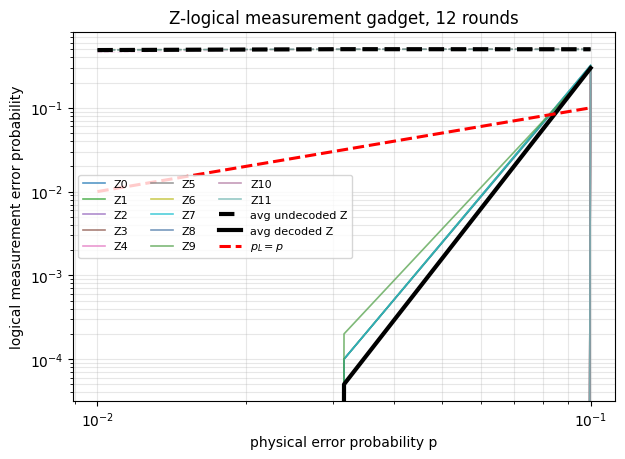

detectors: 2235
observables: 1
L0 terms: 576
X00, p=1.00e-02, raw=0.4788, decoded=0
detectors: 2235
observables: 1
L0 terms: 576
X00, p=3.16e-02, raw=0.5061, decoded=0
detectors: 2235
observables: 1
L0 terms: 576
X00, p=1.00e-01, raw=0.5067, decoded=0.2764
detectors: 1884
observables: 1
L0 terms: 288
X01, p=1.00e-02, raw=0.4193, decoded=0
detectors: 1884
observables: 1
L0 terms: 288
X01, p=3.16e-02, raw=0.4979, decoded=0.0001
detectors: 1884
observables: 1
L0 terms: 288
X01, p=1.00e-01, raw=0.5009, decoded=0.2676
detectors: 2196
observables: 1
L0 terms: 432
X02, p=1.00e-02, raw=0.4748, decoded=0
detectors: 2196
observables: 1
L0 terms: 432
X02, p=3.16e-02, raw=0.5007, decoded=0.0001
detectors: 2196
observables: 1
L0 terms: 432


KeyboardInterrupt: 

In [70]:
# Run cached Z- and X-logical gadget measurements.
logical_measurement_results = {}

for logical_basis, basis_name in [(Pauli.Z, 'Z'), (Pauli.X, 'X')]:
    deformations = logical_measurement_deformations[basis_name]
    raw = np.zeros((len(logical_indices), len(ps)))
    decoded = np.zeros_like(raw)

    for i, logical_i in enumerate(logical_indices):
        for j, p in enumerate(ps):
            raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
                BB_code=BB_code,
                def_res=deformations[i],
                logical_basis=logical_basis,
                logical_index=logical_i,
                p=float(p),
                rounds=rounds,
                shots=shots,
            )
            print(
                f'{basis_name}{logical_i:02d}, p={p:.2e}, '
                f'raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}'
            )

    logical_measurement_results[basis_name] = {
        'ps': ps.copy(),
        'raw': raw,
        'decoded': decoded,
    }

    fig, ax = plt.subplots(figsize=(7, 4.8))

    logical_colors = [
        '#1f77b4', '#2ca02c', '#9467bd', '#8c564b',
        '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#4c78a8', '#54a24b', '#b279a2', '#72b7b2',
    ]

    for i, logical_i in enumerate(logical_indices):
        color = logical_colors[i % len(logical_colors)]
        ax.loglog(ps, raw[i], '--', color=color, alpha=0.22, linewidth=0.9)
        ax.loglog(
            ps,
            decoded[i],
            '-',
            color=color,
            alpha=0.75,
            linewidth=1.2,
            markersize=3,
            label=f'{basis_name}{logical_i}'
        )

    avg_raw = np.mean(raw, axis=0)
    avg_decoded = np.mean(decoded, axis=0)
    ax.loglog(ps, avg_raw, 'k--', linewidth=3.0, label=f'avg undecoded {basis_name}')
    ax.loglog(ps, avg_decoded, 'k-', linewidth=3.0, label=f'avg decoded {basis_name}')

    # pseudo-threshold reference line: logical error = physical error
    ax.loglog(ps, ps, '--', color='red', linewidth=2.2, label=r'$p_L = p$')

    ax.set_title(f'{basis_name}-logical measurement gadget, {rounds} rounds')
    ax.set_xlabel('physical error probability p')
    ax.set_ylabel('logical measurement error probability')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()


## Shuttling vs. planarity

In [84]:
shuttling_thresholds = [0, 1, 2, 3, 30]
ps = np.logspace(-1.5, -0.8, 3)
logical_basis = Pauli.Z
basis_name = "Z"
logical_i = 8
shots = 5000
rounds = 6
raw = np.zeros((len(shuttling_thresholds), len(ps)))
decoded = np.zeros_like(raw)
n_shuttles = []

for i, thresh in enumerate(shuttling_thresholds):
    deformation = get_deformed_logical(
        BB_code,
        logical_basis=logical_basis,
        logical_index=logical_i,
        shuttling_threshold=thresh,
    )
    n_shuttles.append(deformation["n_shuttling_edges"])

    for j, p in enumerate(ps):
        raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
            BB_code=BB_code,
            def_res=deformation,
            logical_basis=logical_basis,
            logical_index=logical_i,
            p=float(p),
            rounds=rounds,
            shots=shots,
        )
        print(
            f"{basis_name}{logical_i:02d}, threshold={thresh}, "
            f"shuttles={n_shuttles[-1]}, p={p:.2e}, "
            f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
        )

shuttling_sweep_results = {
    "ps": ps.copy(),
    "thresholds": np.asarray(shuttling_thresholds),
    "n_shuttles": np.asarray(n_shuttles),
    "raw": raw,
    "decoded": decoded,
}



detectors: 1060
observables: 1
L0 terms: 288
Z08, threshold=0, shuttles=83, p=3.16e-02, raw=0.495, decoded=0
detectors: 1060
observables: 1
L0 terms: 288
Z08, threshold=0, shuttles=83, p=7.08e-02, raw=0.5048, decoded=0.0118
detectors: 1060
observables: 1
L0 terms: 288
Z08, threshold=0, shuttles=83, p=1.58e-01, raw=0.5104, decoded=0.5088
detectors: 1088
observables: 1
L0 terms: 288
Z08, threshold=1, shuttles=31, p=3.16e-02, raw=0.49, decoded=0
detectors: 1088
observables: 1
L0 terms: 288
Z08, threshold=1, shuttles=31, p=7.08e-02, raw=0.5066, decoded=0.0144
detectors: 1088
observables: 1
L0 terms: 288
Z08, threshold=1, shuttles=31, p=1.58e-01, raw=0.4892, decoded=0.5022
detectors: 1151
observables: 1
L0 terms: 288
Z08, threshold=2, shuttles=16, p=3.16e-02, raw=0.5066, decoded=0
detectors: 1151
observables: 1
L0 terms: 288
Z08, threshold=2, shuttles=16, p=7.08e-02, raw=0.5088, decoded=0.0098
detectors: 1151
observables: 1
L0 terms: 288
Z08, threshold=2, shuttles=16, p=1.58e-01, raw=0.498,

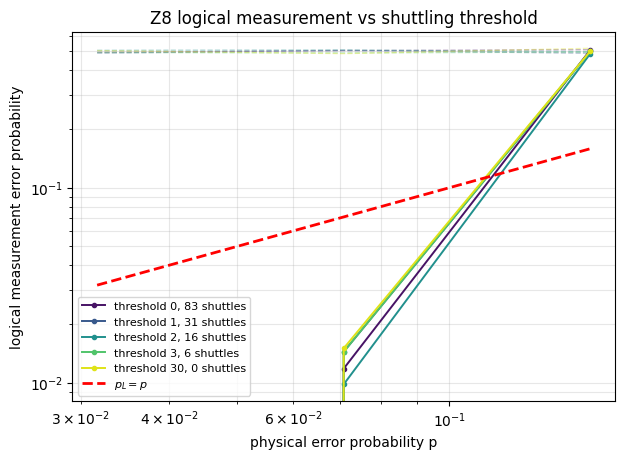

In [85]:
fig, ax = plt.subplots(figsize=(7, 4.8))

colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(shuttling_thresholds)))

for i, thresh in enumerate(shuttling_thresholds):
    label = f"threshold {thresh}, {n_shuttles[i]} shuttles"
    ax.loglog(ps, raw[i], "--", color=colors[i], alpha=0.35, linewidth=1.0)
    ax.loglog(ps, decoded[i], "o-", color=colors[i], linewidth=1.4, markersize=3, label=label)

ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")

ax.set_title(f"{basis_name}{logical_i} logical measurement vs shuttling threshold")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()

## Heterogenous noise

In [90]:
ps = np.logspace(-1.5, -0.8, 3)
logical_basis = Pauli.Z
basis_name = "Z"
logical_i = 8
shots = 5000
rounds = 6
raw = np.zeros((3, len(ps)))
decoded = np.zeros_like(raw)
noise_models = ["gadget", "data", "both"]

for i in range(3):
    deformation = get_deformed_logical(
        BB_code,
        logical_basis=logical_basis,
        logical_index=logical_i,
        shuttling_threshold=2,
    )

    for j, p in enumerate(ps):
        raw[i, j], decoded[i, j] = estimate_logical_measurement_error_rate(
            BB_code=BB_code,
            def_res=deformation,
            logical_basis=logical_basis,
            logical_index=logical_i,
            p=float(p),
            rounds=rounds,
            shots=shots,
            noise_model = noise_models[i]

        )
        print(
            f"raw={raw[i, j]:.4g}, decoded={decoded[i, j]:.4g}"
        )

heterogenous_noise_results = {
    "ps": ps.copy(),
    "noise_models":  noise_models,
    "raw": raw,
    "decoded": decoded,
}

detectors: 1151
observables: 1
L0 terms: 288
raw=0.5, decoded=0
detectors: 1151
observables: 1
L0 terms: 288
raw=0.512, decoded=0.0128
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5008, decoded=0.4908
detectors: 1151
observables: 1
L0 terms: 288
raw=0.4974, decoded=0.0004
detectors: 1151
observables: 1
L0 terms: 288
raw=0.512, decoded=0.014
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5106, decoded=0.4972
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5026, decoded=0
detectors: 1151
observables: 1
L0 terms: 288
raw=0.4994, decoded=0.015
detectors: 1151
observables: 1
L0 terms: 288
raw=0.5112, decoded=0.5012


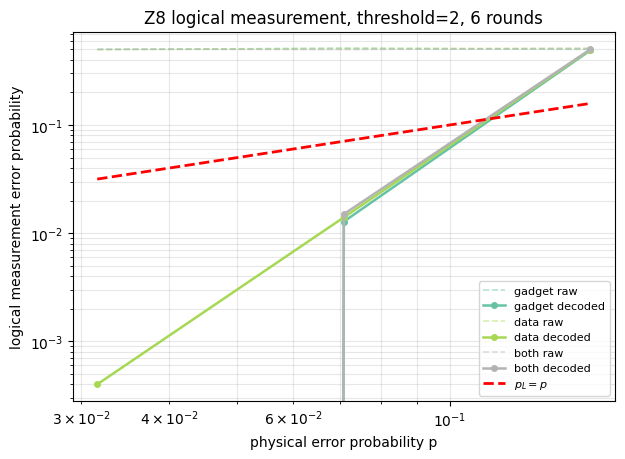

In [91]:
res = heterogenous_noise_results

ps = res["ps"]
noise_models = res["noise_models"]
raw = res["raw"]
decoded = res["decoded"]

fig, ax = plt.subplots(figsize=(7, 4.8))
colors = plt.cm.Set2(np.linspace(0, 1, len(noise_models)))

for i, noise_model in enumerate(noise_models):
    ax.loglog(
        ps,
        raw[i],
        "--",
        color=colors[i],
        alpha=0.45,
        linewidth=1.2,
        label=f"{noise_model} raw",
    )
    ax.loglog(
        ps,
        decoded[i],
        "o-",
        color=colors[i],
        linewidth=1.8,
        markersize=4,
        label=f"{noise_model} decoded",
    )

ax.loglog(ps, ps, "--", color="red", linewidth=2.0, label=r"$p_L=p$")

ax.set_title(f"{basis_name}{logical_i} logical measurement, threshold=2, {rounds} rounds")
ax.set_xlabel("physical error probability p")
ax.set_ylabel("logical measurement error probability")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.show()